# Прогноз оттока и рекомендации по удержанию клиентов для фитнес-центра

## Описание проекта

Сеть фитнес-центров «Культурист-датасаентист» разрабатывает стратегию взаимодействия с клиентами на основе аналитических данных. 
Распространённая проблема фитнес-клубов и других сервисов — отток клиентов. Как понять, что клиент больше не с вами? Можно записать в отток тех, кто попросил закрыть договор или удалил аккаунт. Однако клиенты не всегда уходят демонстративно: чаще перестают пользоваться сервисом тихо. 

Для фитнес-центра можно считать, что клиент попал в отток, если за последний месяц ни разу не посетил спортзал. Конечно, не исключено, что он уехал на Бали и по приезде обязательно продолжит ходить на фитнес. Однако чаще бывает наоборот. Если клиент начал новую жизнь с понедельника, немного походил в спортзал, а потом пропал — скорее всего, он не вернётся. 
Чтобы бороться с оттоком, отдел по работе с клиентами «Культуриста-датасаентиста» перевёл в электронный вид множество клиентских анкет. 

## Задача: 

Провести анализ и подготовить план действий по удержанию клиентов.  
А именно: 
- научиться прогнозировать вероятность оттока (на уровне следующего месяца) для каждого клиента;
- сформировать типичные портреты клиентов: выделить несколько наиболее ярких групп и охарактеризовать их основные свойства;
- проанализировать основные признаки, наиболее сильно влияющие на отток;
- сформулировать основные выводы и разработать рекомендации по повышению качества работы с клиентами:
1. выделить целевые группы клиентов;
2.  предложить меры по снижению оттока;
3.  определить другие особенности взаимодействия с клиентами.


## Описание данных

Для этого в нашем распоряжении сведения в csv-файлах. Заказчик подготовил данные, которые содержат данные на месяц до оттока и факт оттока на определённый месяц. Набор данных включает следующие поля:

1. Данные клиента за предыдущий до проверки факта оттока месяц:
- 'gender' — пол;
- 'Near_Location' — проживание или работа в районе, где находится фитнес-центр;
- 'Partner' — сотрудник компании-партнёра клуба (сотрудничество с компаниями, чьи сотрудники могут получать скидки на абонемент — в таком случае фитнес-центр хранит информацию о работодателе клиента);
- Promo_friends — факт первоначальной записи в рамках акции «приведи друга» (использовал промо-код от знакомого при оплате первого абонемента);
- 'Phone' — наличие контактного телефона;
- 'Age' — возраст;
- 'Lifetime' — время с момента первого обращения в фитнес-центр (в месяцах).
2. Информация на основе журнала посещений, покупок и информация о текущем статусе абонемента клиента:
- 'Contract_period' — длительность текущего действующего абонемента (месяц, 6 месяцев, год);
- 'Month_to_end_contract' — срок до окончания текущего действующего абонемента (в месяцах);
- 'Group_visits' — факт посещения групповых занятий;
- 'Avg_class_frequency_total' — средняя частота посещений в неделю за все время с начала действия абонемента;
- 'Avg_class_frequency_current_month' — средняя частота посещений в неделю за предыдущий месяц;
- 'Avg_additional_charges_total' — суммарная выручка от других услуг фитнес-центра: кафе, спорттовары, косметический и массажный салон.
- 'Churn' — факт оттока в текущем месяце.

Путь к файлу: /datasets/gym_churn.csv

## План Исследования 

**Шаг 1.** Загрузка данных и подготовка к анализу
1. Считаем CSV-файлы с данными с помощью библиотеки pandas и сохраним их в датафреймы. Путь к файлу:
/datasets/gym_churn.csv
2. Выведем первые строки набора данных. Изучим общую информацию о датафрейме.
**Шаг 2.** Исследовательский анализ данных (EDA)
1. Посмотрим на датасет: есть ли в нём отсутствующие значения (пропуски), изучим средние значения и стандартные отклонения (пригодится метод describe());
2. Посмотрим на средние значения признаков в двух группах — тех, кто ушел в отток и тех, кто остался (воспользуемся методом groupby());
3. Построим столбчатые гистограммы и распределения признаков для тех, кто ушёл (отток) и тех, кто остался (не попали в отток);
4. Построим матрицу корреляций и отобразите её.
**Шаг 3.** Построение модели прогнозирования оттока клиентов
1. Построим модель бинарной классификации клиентов, где целевой признак — факт оттока клиента в следующем месяце:
- Разобьем данные на обучающую и валидационную выборку функцией train_test_split().
- Обучим модель на train-выборке двумя способами:
    - логистической регрессией,
    - случайным лесом.
- Оценим метрики accuracy, precision и recall для обеих моделей на валидационной выборке. Сравним по ним модели. Какая модель показала себя лучше на основании метрик?

Не забудем указать параметр random_state при разделении выборки и задании алгоритма.

**Шаг 4.** Кластеризация клиентов
1. Отложим в сторону столбец с оттоком и проведем кластеризацию объектов (клиентов):
- Стандартизируем данные.
- Построем матрицу расстояний функцией linkage() на стандартизованной матрице признаков и нарисуем дендрограмму. Внимание: отрисовка дендрограммы может занять время! На основании полученного графика предположим, какое количество кластеров можно выделить.
- Обучим модель кластеризации на основании алгоритма K-Means и спрогнозируем кластеры клиентов. Договоримся за число кластеров принять n=5. Однако, конечно, в жизни никто не скажет нам правильный ответ, и решение остаётся за нами (на основании изучения графика из предыдущего пункта).
- Посмотрим на средние значения признаков для кластеров. Можно ли сразу что-то заметить?
- Построим распределения признаков для кластеров. Можно ли что-то заметить по ним?
- Для каждого полученного кластера посчитаем долю оттока (методом groupby()). Отличаются ли они по доле оттока? Какие кластеры склонны к оттоку, а какие — надёжны?

**Шаг 5.** Выводы и базовые рекомендации по работе с клиентами
- Сформулируем основные выводы и предложим рекомендации для стратегии взаимодействия с клиентами и их удержания. 
(3-4 важных принципов и примеров их реализации в виде определённых маркетинговых действий.)


In [1]:
#импортируем библиотеки 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from plotly import graph_objects as go
from IPython.display import display
from datetime import datetime, timedelta
from scipy import stats as st
from scipy.stats import binom
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, 
                             roc_auc_score, 
                             f1_score, 
                             precision_score, 
                             recall_score)
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import dendrogram, linkage
import itertools

In [2]:
# определим функцию, которая будет выводить наши метрики
def print_all_metrics(y_true, y_pred, y_proba, title='Метрики классификации'):
    print(title)
    print('\tAccuracy: {:.4f}'.format(accuracy_score(y_true, y_pred)))
    print('\tPrecision: {:.4f}'.format(precision_score(y_true, y_pred)))
    print('\tRecall: {:.4f}'.format(recall_score(y_true, y_pred)))
    print('\tF1: {:.4f}'.format(f1_score(y_true, y_pred)))
    print('\tROC_AUC: {:.4f}'.format(roc_auc_score(y_true, y_proba)))

### Шаг 1. Загружаем данные и подготавливаем их к анализу

Прочитаем данные и получим первое представление о них

In [3]:
#выгрузим данные
gym_churn = pd.read_csv('/datasets/gym_churn.csv')

In [4]:
# Первые строки датафрейма
gym_churn.head()

,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
0,1,1,1,1,0,6,1,29,14.227470,5.0,3,0.020398,0.000000,0
1,0,1,0,0,1,12,1,31,113.202938,12.0,7,1.922936,1.910244,0
2,0,1,1,0,1,1,0,28,129.448479,1.0,2,1.859098,1.736502,0
3,0,1,1,1,1,12,1,33,62.669863,12.0,2,3.205633,3.357215,0
4,1,1,1,1,1,1,0,26,198.362265,1.0,3,1.113884,1.120078,0


In [5]:
gym_churn['gender'].value_counts()

1    2041
0    1959
Name: gender, dtype: int64

Многие признаки указаны в бинарном виде. Поскольку в документации не указано за что считать 0 и за что 1, будем исходить из контекста:
- **gender**(пол):выше проверили по кол-ву, больше значений 1, примем их за мужчин.
     - 0 — женский пол
	 - 1 — мужской пол
- **Near_Location**(Проживание/работа в районе фитнес-центра): 	
     - 0 — Не проживает/не работает в районе фитнес-центра.
	 - 1 — Проживает/работает в районе фитнес-центра.
- **Partner**(Сотрудник компании-партнёра клуба): 
    - 0 — Не является сотрудником компании-партнёра.
	- 1 — Является сотрудником компании-партнёра.
- **Promo_friends**(привлечён в фитнес-центр в рамках акции “приведи друга”): 
    - 0 — Не использовал промо-код от знакомого.
	- 1 — Использовал промо-код от знакомого.
- **Phone**(Наличие контактного телефона):
    - 0 — Нет контактного телефона.
	- 1 — Есть контактный телефон.
- **Group_visits** (Факт посещения групповых занятий): 
    - 0 — Не посещал групповые занятия.
	- 1 — Посещал групповые занятия.
- **Churn**(факт оттока клиента в текущем месяце): 
    - 0 — Не произошло оттока, то есть клиент остался.
	- 1 — Произошёл отток, то есть клиент ушёл.

In [6]:
# распечатаем размер датафрейма
gym_churn.shape

(4000, 14)

Датафрейм среднего размера. Всего 4000 наблюдений и 14 полей — 13 признаков и целевая переменная. Могут ли такие данные сообщить что-то ценное? Давайте посмотрим.

In [7]:
#выводим общую информацию
gym_churn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 14 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   gender                             4000 non-null   int64  
 1   Near_Location                      4000 non-null   int64  
 2   Partner                            4000 non-null   int64  
 3   Promo_friends                      4000 non-null   int64  
 4   Phone                              4000 non-null   int64  
 5   Contract_period                    4000 non-null   int64  
 6   Group_visits                       4000 non-null   int64  
 7   Age                                4000 non-null   int64  
 8   Avg_additional_charges_total       4000 non-null   float64
 9   Month_to_end_contract              4000 non-null   float64
 10  Lifetime                           4000 non-null   int64  
 11  Avg_class_frequency_total          4000 non-null   float

Пропусков нет в данных

Категориальные признаки:

- gender — пол (0 или 1; категориальный, бинарный).
- Near_Location — проживание/работа рядом (0 или 1; категориальный, бинарный).
- Partner — сотрудник компании-партнёра (0 или 1; категориальный, бинарный).
- Promo_friends — участие в акции «приведи друга» (0 или 1; категориальный, бинарный).
- Phone — наличие контактного телефона (0 или 1; категориальный, бинарный).
- Group_visits — факт посещения групповых занятий (0 или 1; категориальный, бинарный).
- Churn — факт оттока (0 или 1; категориальный, бинарный).

Количественные признаки:

- Age — возраст (числовой).
- Lifetime — время с момента первого обращения (числовой).
- Contract_period — длительность текущего абонемента (1, 6, 12 месяцев; числовой).
- Month_to_end_contract — срок до окончания абонемента (числовой).
- Avg_class_frequency_total — средняя частота посещений за весь период (числовой).
- Avg_class_frequency_current_month — средняя частота посещений за последний месяц (числовой).
- Avg_additional_charges_total — суммарная выручка от других услуг (числовой).

Так как задача связана с предсказанием оттока и разработкой рекомендаций на основе факторов, влияющих на него, то Churn — это целевая переменная.

In [8]:
gym_churn.sample(10)

,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
2628,0,0,0,0,1,6,1,28,224.975251,6.0,1,3.077303,3.125544,0
2040,0,0,0,0,1,6,0,26,137.533256,6.0,5,1.044430,1.083924,0
1441,1,1,1,1,1,6,1,30,147.577973,6.0,3,2.057133,2.122973,0
438,1,1,1,1,1,1,0,35,114.210219,1.0,10,0.214234,0.210117,0
2183,1,1,1,1,1,6,1,27,0.148205,6.0,0,0.260201,0.000000,1
3945,0,1,0,0,1,1,0,31,139.665266,1.0,0,1.162560,1.001496,1
1823,0,1,0,0,0,1,1,32,126.001696,1.0,3,3.118453,3.111620,0
1764,1,1,0,0,1,1,1,35,18.233606,1.0,3,2.697339,2.617990,0
3585,0,1,0,0,1,1,0,31,213.816157,1.0,0,2.509591,2.338472,1
3744,1,1,0,0,1,1,0,31,149.020203,1.0,7,1.142254,0.982940,0


###  Шаг 2. Проведем исследовательский анализ данных (EDA)


Теперь проверим на наличие явных дубликатов, пропусков

In [9]:
def primary_analysis2(*dataframes, show_head=True, top_n=5):
    for i, df in enumerate(dataframes, start=1):
        display(f"\n=== Анализ DataFrame {i} ===")

        # Пропуски
        display("\nКоличество пропусков в столбцах:")
        display(df.isnull().sum())
        
        # Явные дубликаты
        display("\nКоличество явных дубликатов:")
        display(df.duplicated().sum())

        # Описание числовых данных
        display("\nСтатистическое описание числовых столбцов:")
        display(df.describe().T.sort_values(by='mean', ascending=False).style.background_gradient(cmap='coolwarm', axis=0).set_precision(2))

In [10]:
primary_analysis2(gym_churn)

'\n=== Анализ DataFrame 1 ==='

'\nКоличество пропусков в столбцах:'

gender                               0
Near_Location                        0
Partner                              0
Promo_friends                        0
Phone                                0
Contract_period                      0
Group_visits                         0
Age                                  0
Avg_additional_charges_total         0
Month_to_end_contract                0
Lifetime                             0
Avg_class_frequency_total            0
Avg_class_frequency_current_month    0
Churn                                0
dtype: int64

'\nКоличество явных дубликатов:'

0

'\nСтатистическое описание числовых столбцов:'

,count,mean,std,min,25%,50%,75%,max
Avg_additional_charges_total,4000.00,146.94,96.36,0.15,68.87,136.22,210.95,552.59
Age,4000.00,29.18,3.26,18.00,27.00,29.00,31.00,41.00
Contract_period,4000.00,4.68,4.55,1.00,1.00,1.00,6.00,12.00
Month_to_end_contract,4000.00,4.32,4.19,1.00,1.00,1.00,6.00,12.00
Lifetime,4000.00,3.72,3.75,0.00,1.00,3.00,5.00,31.00
Avg_class_frequency_total,4000.00,1.88,0.97,0.00,1.18,1.83,2.54,6.02
Avg_class_frequency_current_month,4000.00,1.77,1.05,0.00,0.96,1.72,2.51,6.15
Phone,4000.00,0.90,0.30,0.00,1.00,1.00,1.00,1.00
Near_Location,4000.00,0.85,0.36,0.00,1.00,1.00,1.00,1.00
gender,4000.00,0.51,0.50,0.00,0.00,1.00,1.00,1.00


- По полу равномерное распределение (примерно поровну)
- около 85% живут/работают в районе нахождения фитнес-центра
- примерно половина является сотрудником компании-партнёра клуба 
- около 30% пользователей воспользовались акцией «приведи друга»
- телефон указали 90% пользователей
- средний возраст примерно 29 лет
- среднее время с момента первого обращения в фитнес-центр (в месяцах) почти 4 месяца
- длительность текущего действующего абонемента (месяц, 6 месяцев, год) почти 5 месяцев 
- срок до окончания текущего действующего абонемента (в месяцах): примерно 4 месяца
- посещают групповые занятия примерно 40% посетителей фитнес-центра
- средняя частота посещений в неделю за все время с начала действия абонемента: 1.87(примерно 2) в неделю
- средняя частота посещений в неделю за предыдущий месяц: 1.76(примерно 2) в неделю
- суммарная выручка от других услуг фитнес-центра: кафе, спорттовары, косметический и массажный салон: в среднем 146
- факт оттока в текущем месяце равен примерно 27%

Посмотрим на средние значения признаков в двух группах — тех, кто ушел в отток и тех, кто остался (воспользуемся методом groupby())

In [11]:
def compare_churn_groups3(dataframe):
    """
    Функция для расчета средних значений признаков в группах по факту оттока (Churn) и построения графиков
    для бинарных и числовых признаков (гистограмма с KDE и boxplot).
    
    Аргументы:
    dataframe : pd.DataFrame
        Данные с колонкой 'Churn', содержащей информацию об оттоке клиентов.
    
    Возвращает:
    pd.DataFrame
        Средние значения признаков в группах по оттоку.
    """
    
    # Используем pivot_table для агрегации данных
    mean_values = dataframe.pivot_table(values=dataframe.columns.difference(['Churn']), 
                                        index='Churn', 
                                        aggfunc='mean')
    
    # Применяем стиль для таблицы
    styled_mean_values = mean_values.style.background_gradient(cmap='coolwarm', axis=1).set_precision(2)
    display(styled_mean_values)
    
    # Выбираем только бинарные признаки (которые имеют значения 0 и 1)
    binary_columns = [col for col in dataframe.columns if dataframe[col].nunique() == 2]
    
    # Построение графиков для бинарных признаков
    for feature in binary_columns:
        plt.figure(figsize=(8, 5))
        sns.countplot(data=dataframe, x=feature, hue='Churn', palette='viridis')
        plt.title(f'Распределение признака {feature} по каждой группе', fontsize=14)
        plt.ylabel('Количество', fontsize=12)
        plt.xlabel(feature, fontsize=12)
        plt.legend(title='Churn', labels=['Остались (0)', 'Ушли (1)'])
        plt.tight_layout()
        plt.show()
    
    # Числовые признаки для построения графиков
    numerical_columns = [
        'Age', 
        'Lifetime', 
        'Contract_period', 
        'Month_to_end_contract', 
        'Avg_class_frequency_total', 
        'Avg_class_frequency_current_month', 
        'Avg_additional_charges_total'
    ]
    
    # Фильтрация числовых признаков (если столбцы представлены числами)
    numerical_columns = [col for col in numerical_columns if dataframe[col].dtype in ['float64', 'int64']]
    
    num_features = len(numerical_columns)
    
    if num_features == 0:
        print("Нет числовых признаков для построения графиков.")
        return
    
    # Создаем подграфики для числовых признаков: по 2 столбца на каждый признак
    fig, axes = plt.subplots(num_features, 2, figsize=(12, 5 * num_features))
    
    # Если признаков только один, axes будет не массивом, а единственным объектом, поэтому нужно привести его к массиву
    if num_features == 1:
        axes = [axes]
    
    # Построение графиков для числовых признаков
    for i, feature in enumerate(numerical_columns):
        # Гистограмма с KDE линией (на первом столбце)
        sns.histplot(dataframe[feature], kde=True, ax=axes[i][0], color='skyblue', bins=30)
        axes[i][0].set_title(f'Гистограмма для {feature}', fontsize=15)
        axes[i][0].set_xlabel(feature, fontsize=12)
        axes[i][0].set_ylabel('Частота', fontsize=12)
        
        # Boxplot (на втором столбце)
        sns.boxplot(data=dataframe, x=feature, ax=axes[i][1], color='lightgreen')
        axes[i][1].set_title(f'Boxplot для {feature}', fontsize=15)
        axes[i][1].set_xlabel(feature, fontsize=12)
        axes[i][1].set_ylabel('Значение', fontsize=12)
    
    plt.tight_layout()
    plt.show()

,Age,Avg_additional_charges_total,Avg_class_frequency_current_month,Avg_class_frequency_total,Contract_period,Group_visits,Lifetime,Month_to_end_contract,Near_Location,Partner,Phone,Promo_friends,gender
Churn,,,,,,,,,,,,,
0,29.98,158.45,2.03,2.02,5.75,0.46,4.71,5.28,0.87,0.53,0.90,0.35,0.51
1,26.99,115.08,1.04,1.47,1.73,0.27,0.99,1.66,0.77,0.36,0.90,0.18,0.51


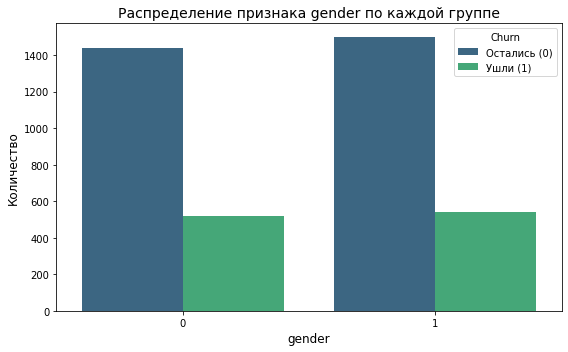

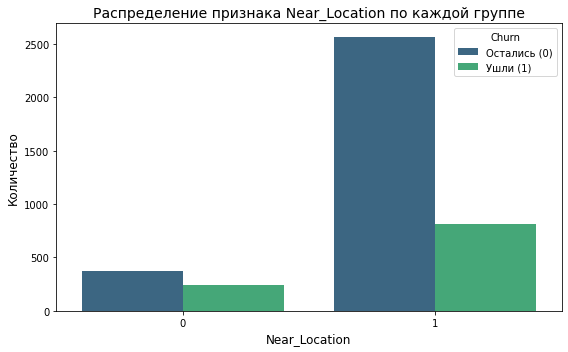

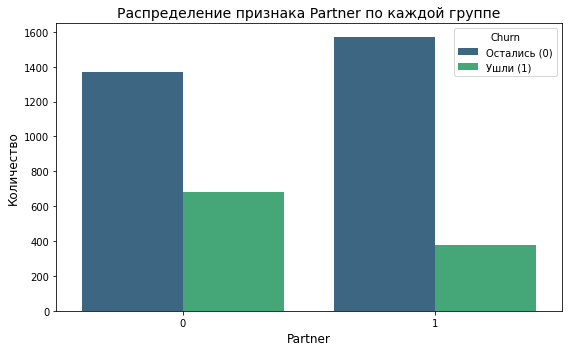

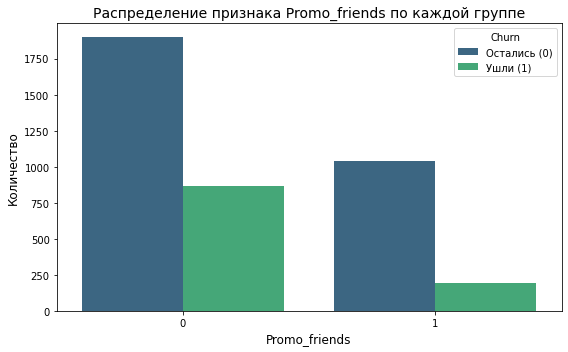

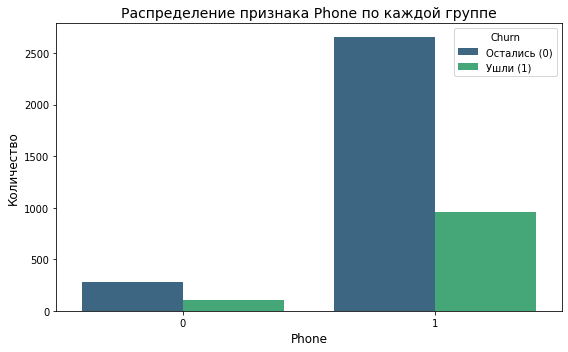

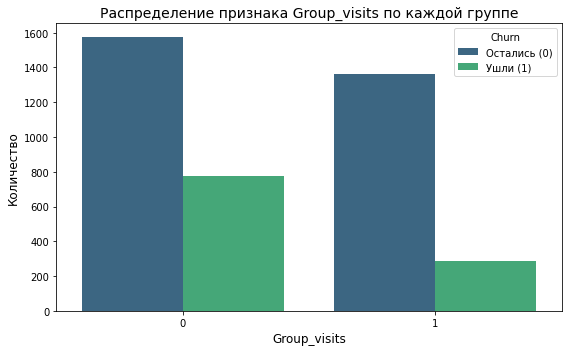

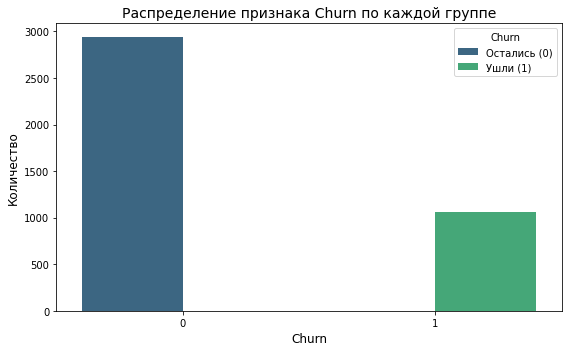

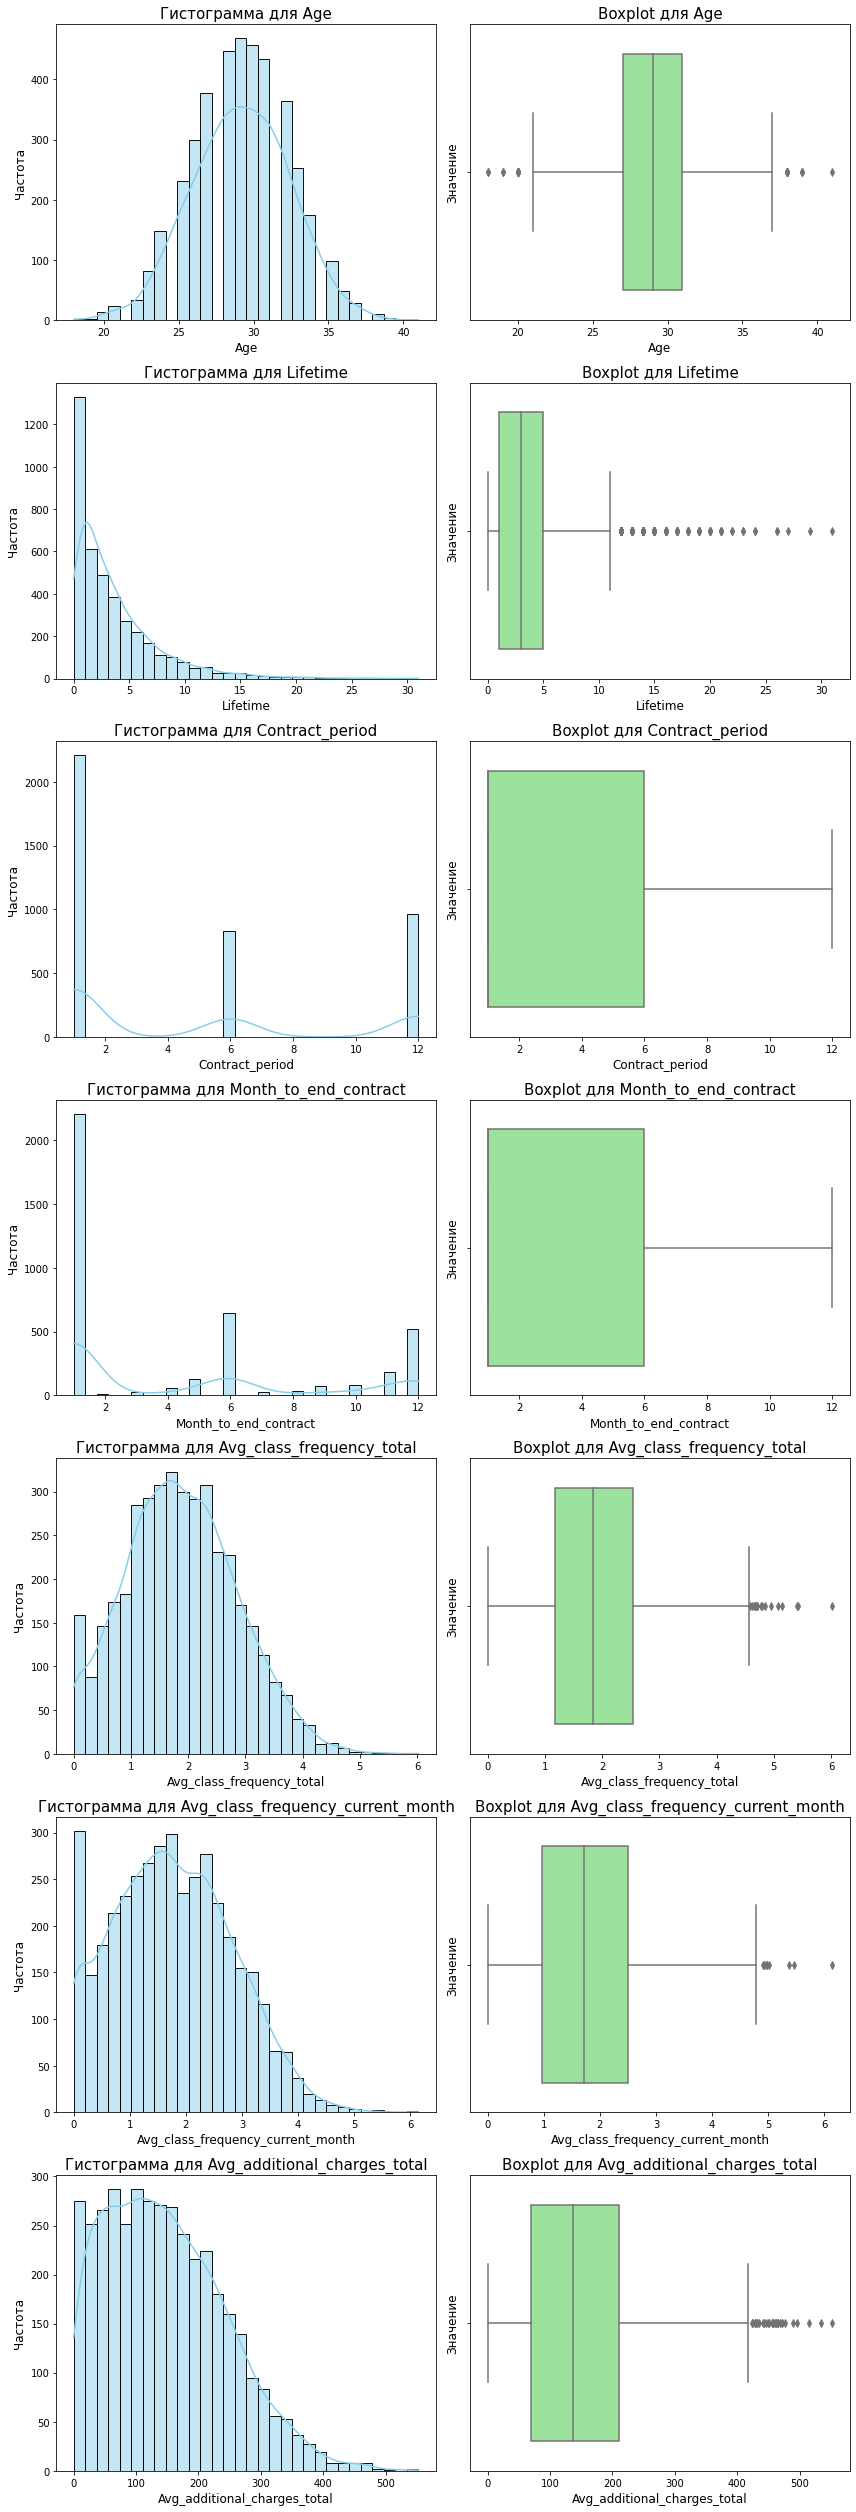

In [12]:
compare_churn_groups3(gym_churn)

Во всех случаях ушедших людей меньше, чем оставшихся
- по полу: распределение равномерное у обоих групп
- по близости к фитнес-центру: в группе оставшихся пользователей больше тех, кто живет рядом, чем в группе оттока
- по тому, является ли клиент сотрудником партнера или пришел по акции: в основном те, кто в группе оттока, не являются сотрудниками партнерской компании и не пришли по акции, а в группе оставшихся распределение поровну
- по наличию указанного контактного номера: в обеих группах в основном указаны номера 
- по длительности текущего действующего абонемента: группа оттока в основном с коротким абонементом(1-2 мес), а у второй группы около 5-6 мес
- по возрасту: у оставшихся средний возраст 30 лет, у тех, кто покинул фитнес-центр, средний возраст 27 лет
- по доп.выручке: выручка от тех, кто остается и имеет более длительный абонемент, больше(158), чем у тех, кто ушел в отток(115)
- по времени с момента первого обращения в фитнес-центр (в месяцах): у группы оттока это значение примерно 1 мес, а у тех, кто остается -- около 5 мес
- по посещению групповых занятий: ушедшие в отток в основном не посещают групповые занятия, а остальные(оставшиеся) в половине случаев посещают

вычислим корреляционную матрицу и нарисуем на её основе heatmap() с аннотацией;
функцией scatterplot() построим попарные корреляции между каждым признаком и целевой переменной
Это поможет понять:

- Какие признаки могут быть наиболее ценными для модели исходя из корреляций.
- Какие полезные признаки можно попробовать сгенерировать самостоятельно на основе уже имеющихся.
- Насколько полезной вообще может быть модель с таким качеством исходных данных. Если многие признаки слишком шумны и изменчивы, уже в самом начале важно это признать и не ждать, что ML совершит чудо.

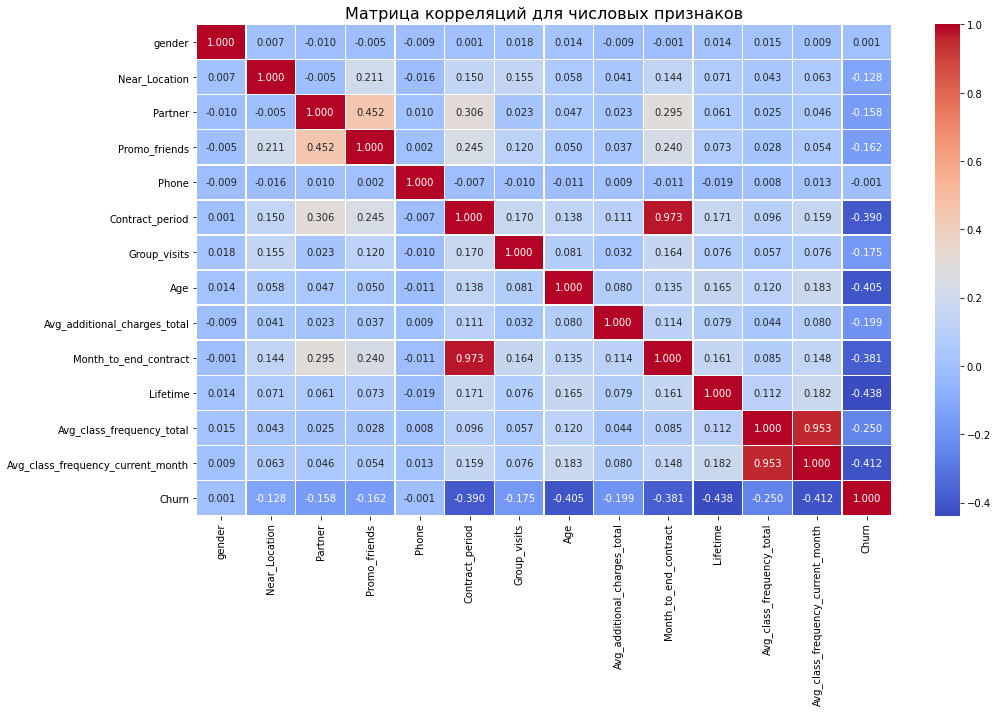

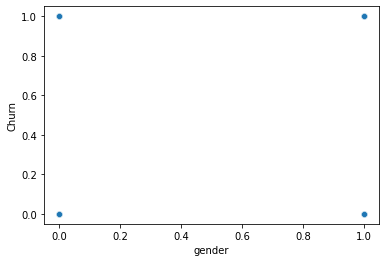

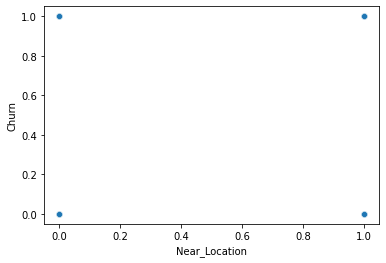

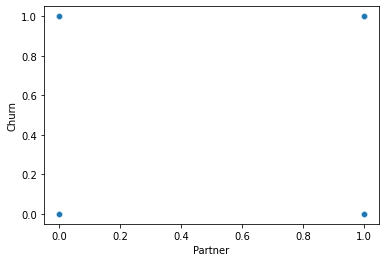

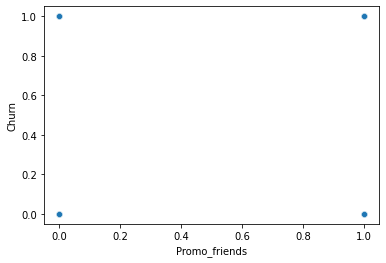

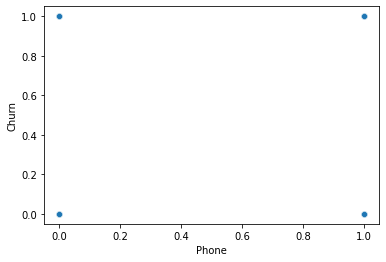

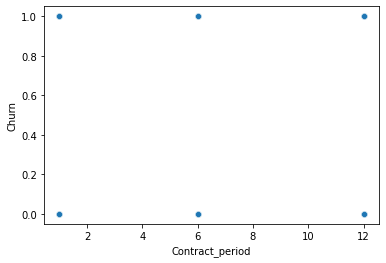

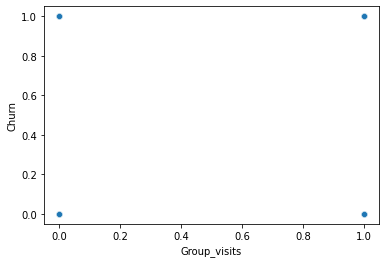

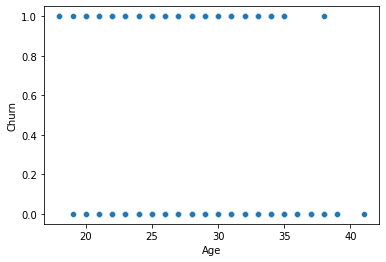

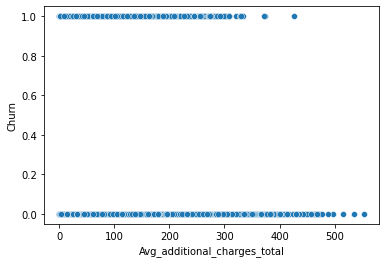

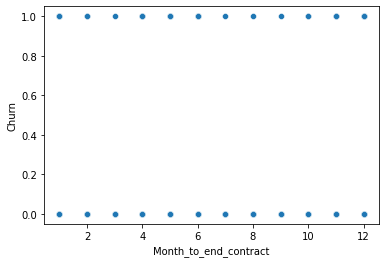

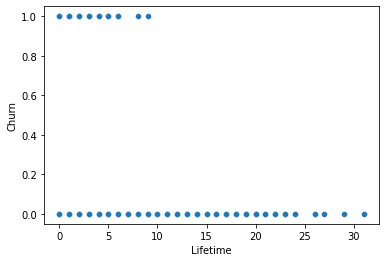

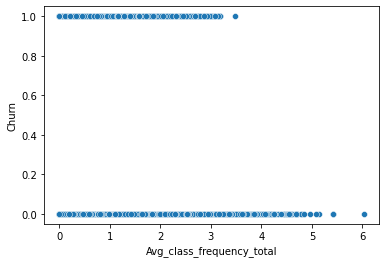

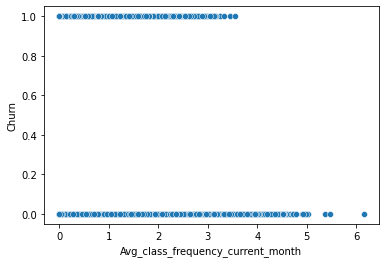

In [13]:
#построим и отрисуем матрицу корреляций
cm = gym_churn.corr() #вычисляем матрицу корреляций

# Устанавливаем размер графика
plt.figure(figsize=(15, 10))
#нарисуем тепловую карту с подписями для матрицы корреляций
ax = sns.heatmap(cm, annot=True, cmap='coolwarm', fmt='.3f', linewidths=0.5)
plt.title('Матрица корреляций для числовых признаков', fontsize=16)
plt.tight_layout()
ax.set_ylim(len(cm), 0)  # Указываем границы оси Y
# корректировка "рваных" полей heatmap в последней версии библиотеки
plt.show() 

#построим попарные диаграммы рассеяния признак-целевая переменная для каждого признака
for col in gym_churn.drop('Churn', axis = 1).columns:
    sns.scatterplot(x=gym_churn[col], y=gym_churn['Churn'])
    plt.show()

Каких-то ярких выбросов и перекосов по диаграммам рассеяния не наблюдается. Это отлично. Значит, на этих данных можно строить модель. 
Что касается корреляций и попарных графиков — мы уже можем заметить, что нет какой-то заметной корреляции между целевой переменной и признаками. 

1. Высокая корреляция между Month_to_end_contract и Lifetime (0.97)

2. Сильная корреляция между Avg_class_frequency_total и Avg_class_frequency_current_month (0.95)

3. Можно заметить отрицательную корреляцию между фактом оттока и различными признаками: самая низкая корреляция со  временными признаками и возрастом. Самая высокая с полом и наличием контактного номера телефона

### Шаг 3. Построение модель прогнозирования оттока клиентов

Построим модель бинарной классификации клиентов, где целевой признак — факт оттока клиента в следующем месяце:

Разбьем данные на обучающую и валидационную выборку функцией train_test_split()

In [14]:
# Разделение данных на признаки и целевую переменную
X = gym_churn.drop(columns=['Churn'], axis=1)  # Признаки
y = gym_churn['Churn']  # Целевая переменная

# Разделение на обучающую и тестовую выборку с использованием stratify
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0, stratify=y
)

# Стандартизация данных: обучаем на обучающей выборке
scaler = StandardScaler()
scaler.fit(X_train)

# Преобразование обучающего и тестового набора
X_train_st = scaler.transform(X_train)
X_test_st = scaler.transform(X_test)

Обучим модель на train-выборке двумя способами:
- логистической регрессией,
- случайным лесом.

In [15]:
# Логистическая регрессия
lr_model = LogisticRegression(random_state=0)
lr_model.fit(X_train_st, y_train)
lr_predictions = lr_model.predict(X_test_st)
lr_probabilities = lr_model.predict_proba(X_test_st)[:, 1]

# Метрики для логистической регрессии
print_all_metrics(
    y_test,
    lr_predictions,
    lr_probabilities,
    title='Метрики для модели логистической регрессии:'
)

# Случайный лес
rf_model = RandomForestClassifier(random_state=0, n_estimators=100)
rf_model.fit(X_train_st, y_train)
rf_predictions = rf_model.predict(X_test_st)
rf_probabilities = rf_model.predict_proba(X_test_st)[:, 1]

# Метрики для случайного леса
print_all_metrics(
    y_test, 
    rf_predictions,
    rf_probabilities,
    title='Метрики для модели случайного леса:'
)

Метрики для модели логистической регрессии:
	Accuracy: 0.9350
	Precision: 0.8960
	Recall: 0.8538
	F1: 0.8744
	ROC_AUC: 0.9780
Метрики для модели случайного леса:
	Accuracy: 0.9225
	Precision: 0.8750
	Recall: 0.8255
	F1: 0.8495
	ROC_AUC: 0.9703


Для RF можно в цикле поперебирать лучшие гиперпараметр, чтобы улучшить метрику

А для этого предварительно создаём валидационную выборку X_val, y_val. И смотрим метрику на ней, для разных гиперпараметров

И таким образом можно найти лучшее значение n_estimators и depth

Попробовать передать в модель параметр учитывающий дисбланас классов

In [16]:
# Разделяем данные на обучающую, валидационную и тестовую выборки
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=0)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=0)

# Стандартизация данных
scaler = StandardScaler()
scaler.fit(X_train)

X_train_st = scaler.transform(X_train)
X_val_st = scaler.transform(X_val)
X_test_st = scaler.transform(X_test)

# Подбор гиперпараметров на основе данных из train и val
for est in range(50, 151, 50):
    for depth in range(5, 16, 5):
        # Создание и обучение модели с использованием стандартизированных данных
        model = RandomForestClassifier(random_state=0, n_estimators=est, max_depth=depth)
        model.fit(X_train_st, y_train)

        # Предсказание на валидационной выборке
        y_pred = model.predict(X_val_st)

        # Оценка модели с помощью метрик
        accuracy = accuracy_score(y_val, y_pred)
        precision = precision_score(y_val, y_pred, zero_division=1)  # Добавлен zero_division для избегания ошибки при делении на ноль
        recall = recall_score(y_val, y_pred, zero_division=1)
        f1 = f1_score(y_val, y_pred, zero_division=1)

        # Вывод результатов с точностью до 4 знаков после запятой
        print(f"n_estimators: {est}, max_depth: {depth}, Accuracy: {accuracy:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1: {f1:.4f}")

n_estimators: 50, max_depth: 5, Accuracy: 0.8933, Precision: 0.8497, Recall: 0.7602, F1: 0.8025
n_estimators: 50, max_depth: 10, Accuracy: 0.9167, Precision: 0.8667, Recall: 0.8363, F1: 0.8512
n_estimators: 50, max_depth: 15, Accuracy: 0.9150, Precision: 0.8704, Recall: 0.8246, F1: 0.8468
n_estimators: 100, max_depth: 5, Accuracy: 0.8917, Precision: 0.8487, Recall: 0.7544, F1: 0.7988
n_estimators: 100, max_depth: 10, Accuracy: 0.9133, Precision: 0.8650, Recall: 0.8246, F1: 0.8443
n_estimators: 100, max_depth: 15, Accuracy: 0.9183, Precision: 0.8765, Recall: 0.8304, F1: 0.8529
n_estimators: 150, max_depth: 5, Accuracy: 0.8917, Precision: 0.8487, Recall: 0.7544, F1: 0.7988
n_estimators: 150, max_depth: 10, Accuracy: 0.9100, Precision: 0.8589, Recall: 0.8187, F1: 0.8383
n_estimators: 150, max_depth: 15, Accuracy: 0.9217, Precision: 0.8827, Recall: 0.8363, F1: 0.8589


Для каждой комбинации были рассчитаны метрики: Accuracy, Precision, Recall и F1. Полученные результаты показывают улучшение метрик с увеличением глубины деревьев и числа деревьев.

n_estimators: 150, max_depth: 15 - лучшие гиперпараметры по результатам метрик

Валидационная выборка свою функцию выполнила, и теперь мы можем дообучить модель на лучших гиперпараметрах на train+valid

In [17]:
# увеличиваем объем обучающей выборки, чтобы дать модели больше данных для обучения.
# объединяем обучающую и валидационную выборки
X_combined = np.vstack((X_train_st, X_val_st))
y_combined = np.hstack((y_train, y_val))

# Случайный лес
rf_model = RandomForestClassifier(random_state=0, n_estimators=150, max_depth=15, class_weight='balanced')
rf_model.fit(X_train_st, y_train)
rf_predictions = rf_model.predict(X_test_st)
rf_probabilities = rf_model.predict_proba(X_test_st)[:, 1]

# Метрики для случайного леса
print_all_metrics(
    y_test, 
    rf_predictions,
    rf_probabilities,
    title='Метрики для модели случайного леса:'
)

Метрики для модели случайного леса:
	Accuracy: 0.9083
	Precision: 0.8309
	Recall: 0.7793
	F1: 0.8043
	ROC_AUC: 0.9680


- Логистическая регрессия демонстрирует лучшие метрики по Accuracy, Precision и Recall, хоть и с небольшим отрывом.
- Если задача компании заключается в максимальном выявлении всех клиентов, которые могут уйти (Recall), логистическая регрессия предпочтительнее. Это важно, если пропускать отток нежелательно.

In [18]:
coefficients = pd.DataFrame(lr_model.coef_.flatten(), X_train.columns, columns=["Coefficient"])

# Сортируем по абсолютным значениям коэффициентов
coefficients['abs_coefficient'] = coefficients['Coefficient'].abs()
coefficients = coefficients.sort_values(by="abs_coefficient", ascending=False)

# Выводим важнейшие признаки
print(coefficients.head())

                                   Coefficient  abs_coefficient
Avg_class_frequency_current_month    -4.213410         4.213410
Lifetime                             -3.581257         3.581257
Avg_class_frequency_total             3.111962         3.111962
Age                                  -1.167067         1.167067
Contract_period                      -0.703639         0.703639


### Шаг 4. Сделаем кластеризацию клиентов
Отложим в сторону столбец с оттоком и проведем кластеризацию объектов (клиентов):

- Стандартизируем данные.
- Построем матрицу расстояний функцией linkage() на стандартизованной матрице признаков и нарисуем дендрограмму. Внимание: отрисовка дендрограммы может занять время! На основании полученного графика предположим, какое количество кластеров можно выделить.
- Обучим модель кластеризации на основании алгоритма K-Means и спрогнозируем кластеры клиентов. Договоримся за число кластеров принять n=5. Однако, конечно, в жизни никто не скажет нам правильный ответ, и решение остаётся за нами (на основании изучения графика из предыдущего пункта).
- Посмотрим на средние значения признаков для кластеров. Можно ли сразу что-то заметить?
- Построим распределения признаков для кластеров. Можно ли что-то заметить по ним?
- Для каждого полученного кластера посчитаем долю оттока (методом groupby()). Отличаются ли они по доле оттока? Какие кластеры склонны к оттоку, а какие — надёжны?

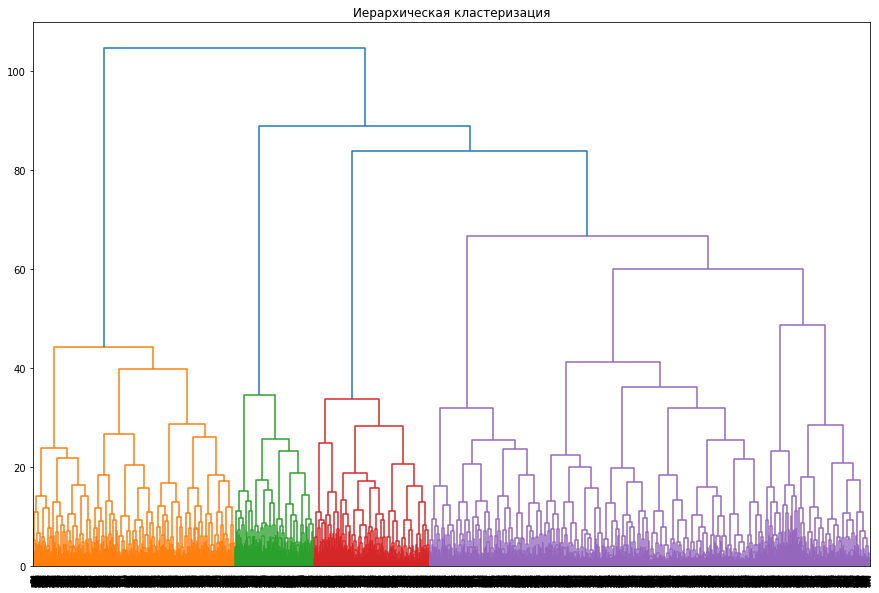

In [19]:
# обязательная стандартизация данных перед работой с алгоритмами
sc = StandardScaler()
X_sc = sc.fit_transform(X)

linked = linkage(X_sc, method = 'ward')

plt.figure(figsize=(15, 10))  
dendrogram(linked, orientation='top')
plt.title('Иерархическая кластеризация')
plt.show()
km = KMeans(n_clusters=5, random_state=0) # задаём число кластеров, равное 5, и фиксируем значение random_state для воспроизводимости результата
labels = km.fit_predict(X_sc) # применяем алгоритм к данным и формируем вектор кластеров
# сохраняем метки кластера в поле нашего датасета
gym_churn['cluster_km'] = labels

На дендрограмме можно заметить 4 крупных ветви. Одно из этих объединений можно разделить на подгруппы, так как оно довольно большое. Поэтому выделим 5 кластеров.

In [20]:
import pandas as pd

# Группировка данных по кластеру и расчет средних значений
cluster_means = round(gym_churn.groupby('cluster_km').mean(), 3)

# Раскраска минимальных и максимальных значений для каждого признака
cluster_features = gym_churn.groupby('cluster_km').mean().reset_index()

# Убираем столбец 'cluster_km'
numeric_columns = cluster_features.drop(columns=['cluster_km']).columns

# Применение форматирования и подсветки максимальных и минимальных значений
styled_cluster_features = cluster_features.drop(columns=['cluster_km']) \
    .style.format({i: '{:.2f}' for i in numeric_columns}) \
    .highlight_max(color='yellowgreen', subset=numeric_columns) \
    .highlight_min(color='coral', subset=numeric_columns)

# Показываем таблицу
styled_cluster_features

# Применяем градиент для всей таблицы
cluster_features.drop(columns=['cluster_km']).T.style.background_gradient(cmap='coolwarm', axis=1).set_precision(2)

,0,1,2,3,4
gender,0.50,0.52,0.50,0.49,0.56
Near_Location,0.96,0.86,0.00,1.00,0.98
Partner,0.78,0.47,0.46,0.35,0.36
Promo_friends,0.57,0.31,0.08,0.24,0.23
Phone,1.00,0.00,1.00,1.00,1.00
Contract_period,10.89,4.79,2.35,1.95,2.67
Group_visits,0.54,0.43,0.22,0.34,0.47
Age,29.98,29.30,28.48,28.17,30.13
Avg_additional_charges_total,160.76,143.96,135.46,131.62,161.66
Month_to_end_contract,9.95,4.48,2.20,1.86,2.46


Средние значения признаков по кластерам позволяют сделать выводы о характеристиках клиентов в каждом кластере и их вероятности оттока (Churn). Вот анализ по кластерам:

1. Кластер 0: отток самый низкий(0.028)
- распределение равномерное по полу, живут близко к фитнес-центру(0.96), Большинство клиентов имеют корпоративное партнерство (Partner = 0.78) и часто приходят через друзей по акции (Promo_friends = 0.57), телефоны указаны, средний возраст 30 лет, средние контракты по продолжительности долгосрочные(почти 10 мес), по доп. выручке 161

2. Кластер 1: отток составил 0.27
- распределение равномерное по полу, живут близко к фитнес-центру(0.86), большинство не является сотрудниками партнеров(0.47) и пришли не по акции(0.30), телефоны не указаны, средний возраст 29 лет, средние контракты по продолжительности(почти 5 мес), по доп. выручке 144

3. Кластер 2: отток высокий, составил 0.44
- распределение примерно равномерное по полу, живут не рядом с фитнес-центром(0), большинство не является сотрудниками партнеров(0.47) и пришли не по акции(0.079), телефоны указаны, средний возраст 28 лет, недолгосрочные контракты по продолжительности(почти 2 мес), по доп. выручке 135

4. Кластер 3: отток самый высокий, составил 0.51
- по полу преобладают женщин, живут рядом с клубом (Near_Location = 0.1), большинство не является сотрудниками партнеров(0.35) и пришли не по акции(0.24), телефоны указаны, средний возраст 28 лет, недолгосрочные контракты по продолжительности(почти 2 мес), по доп. выручке 131

4. Кластер 4: отток низкий, составил 0.068
- по полу преобладают мужчины, практически все клиенты живут рядом с клубом (Near_Location = 0.97), большинство не является сотрудниками партнеров(0.35) и пришли не по акции(0.23), телефоны указаны, средний возраст 30 лет, недолгосрочные контракты по продолжительности(примерно 2.5 мес), по доп. выручке 161

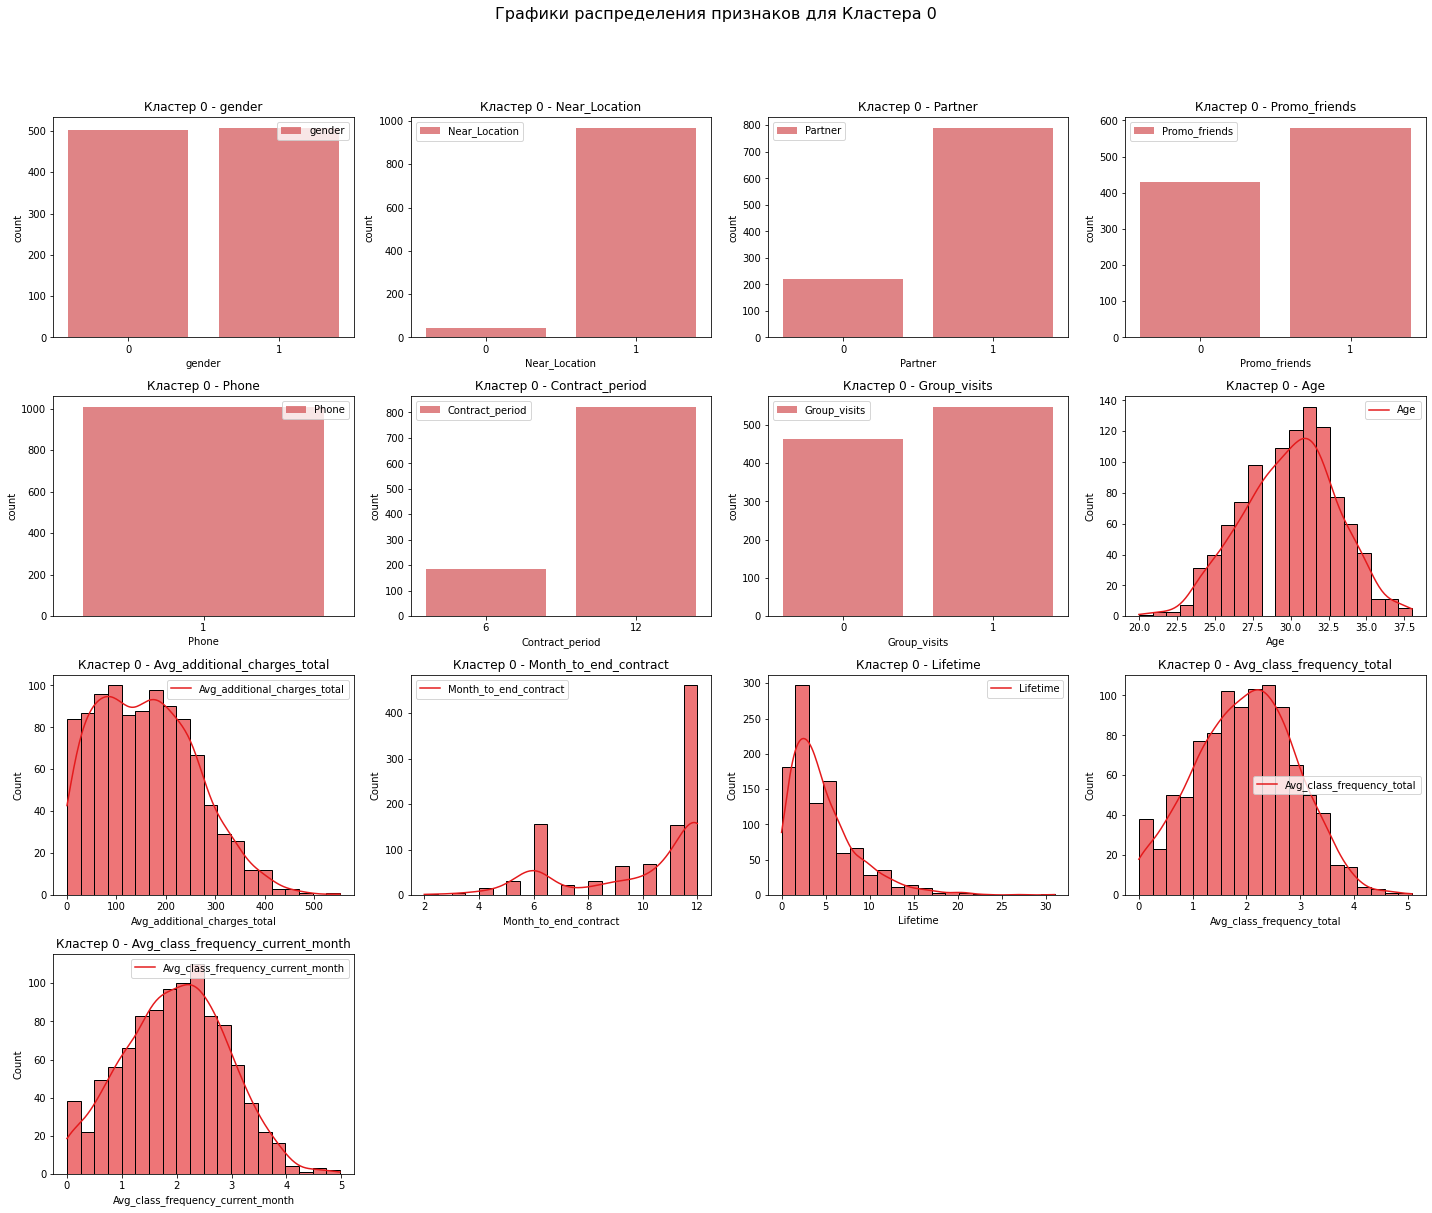

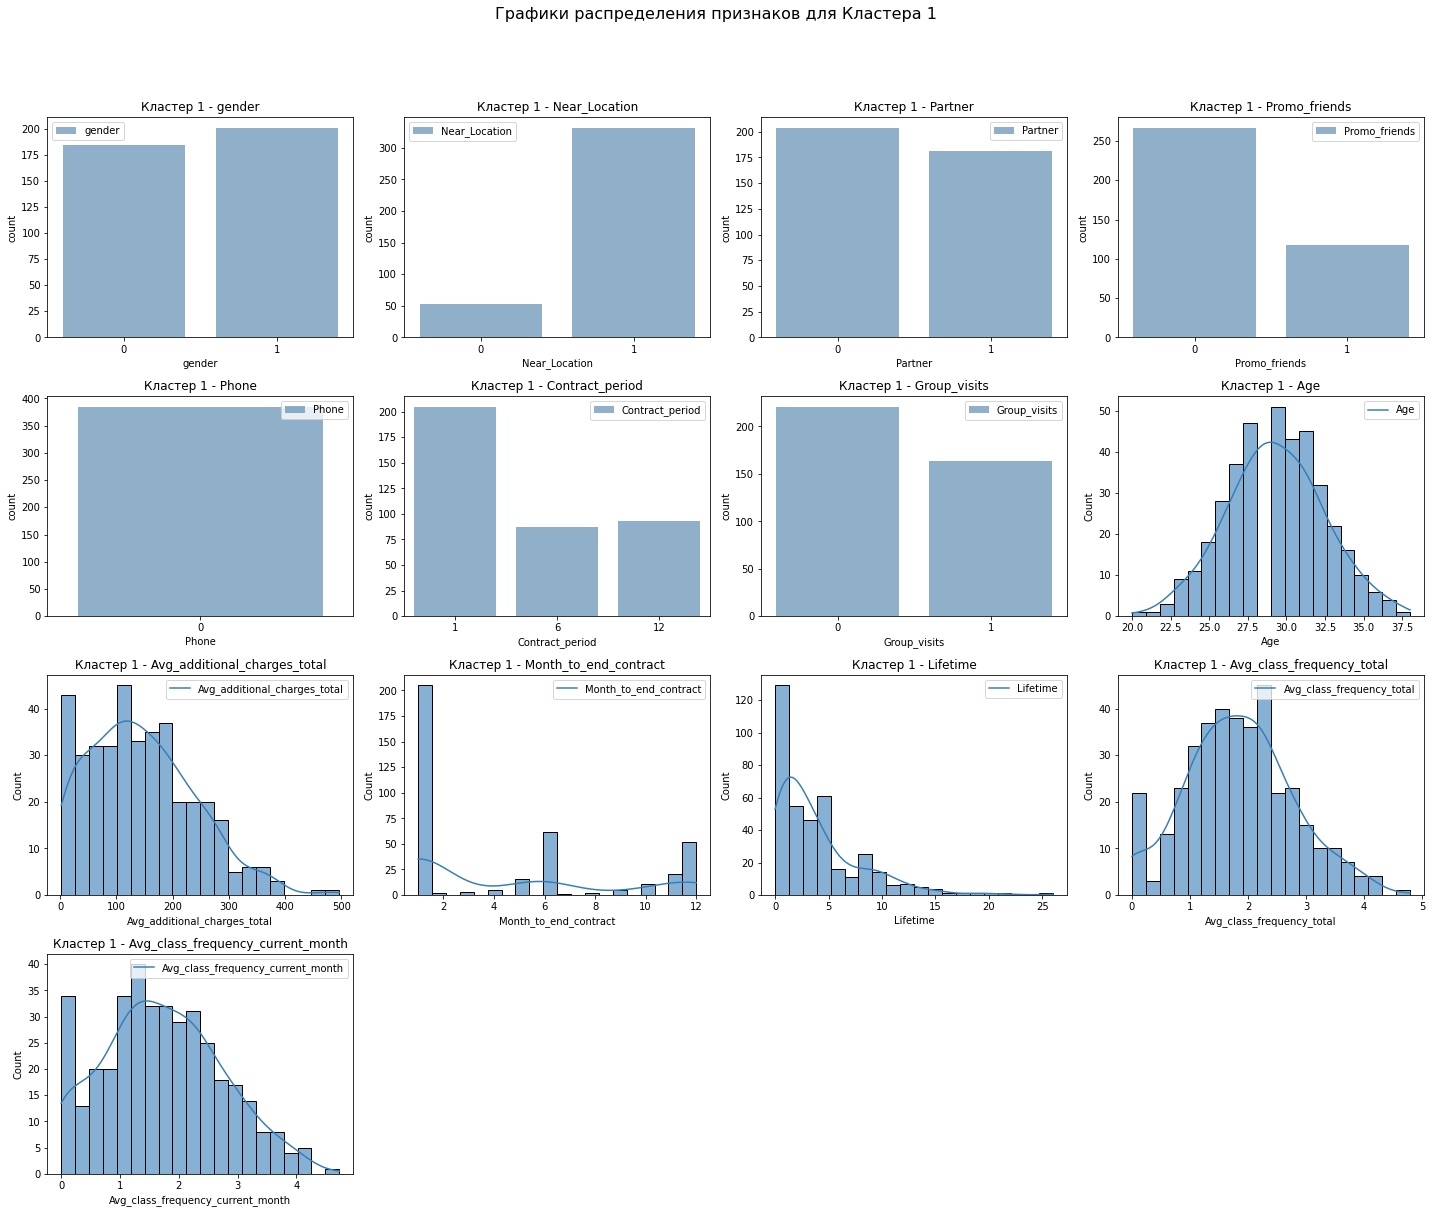

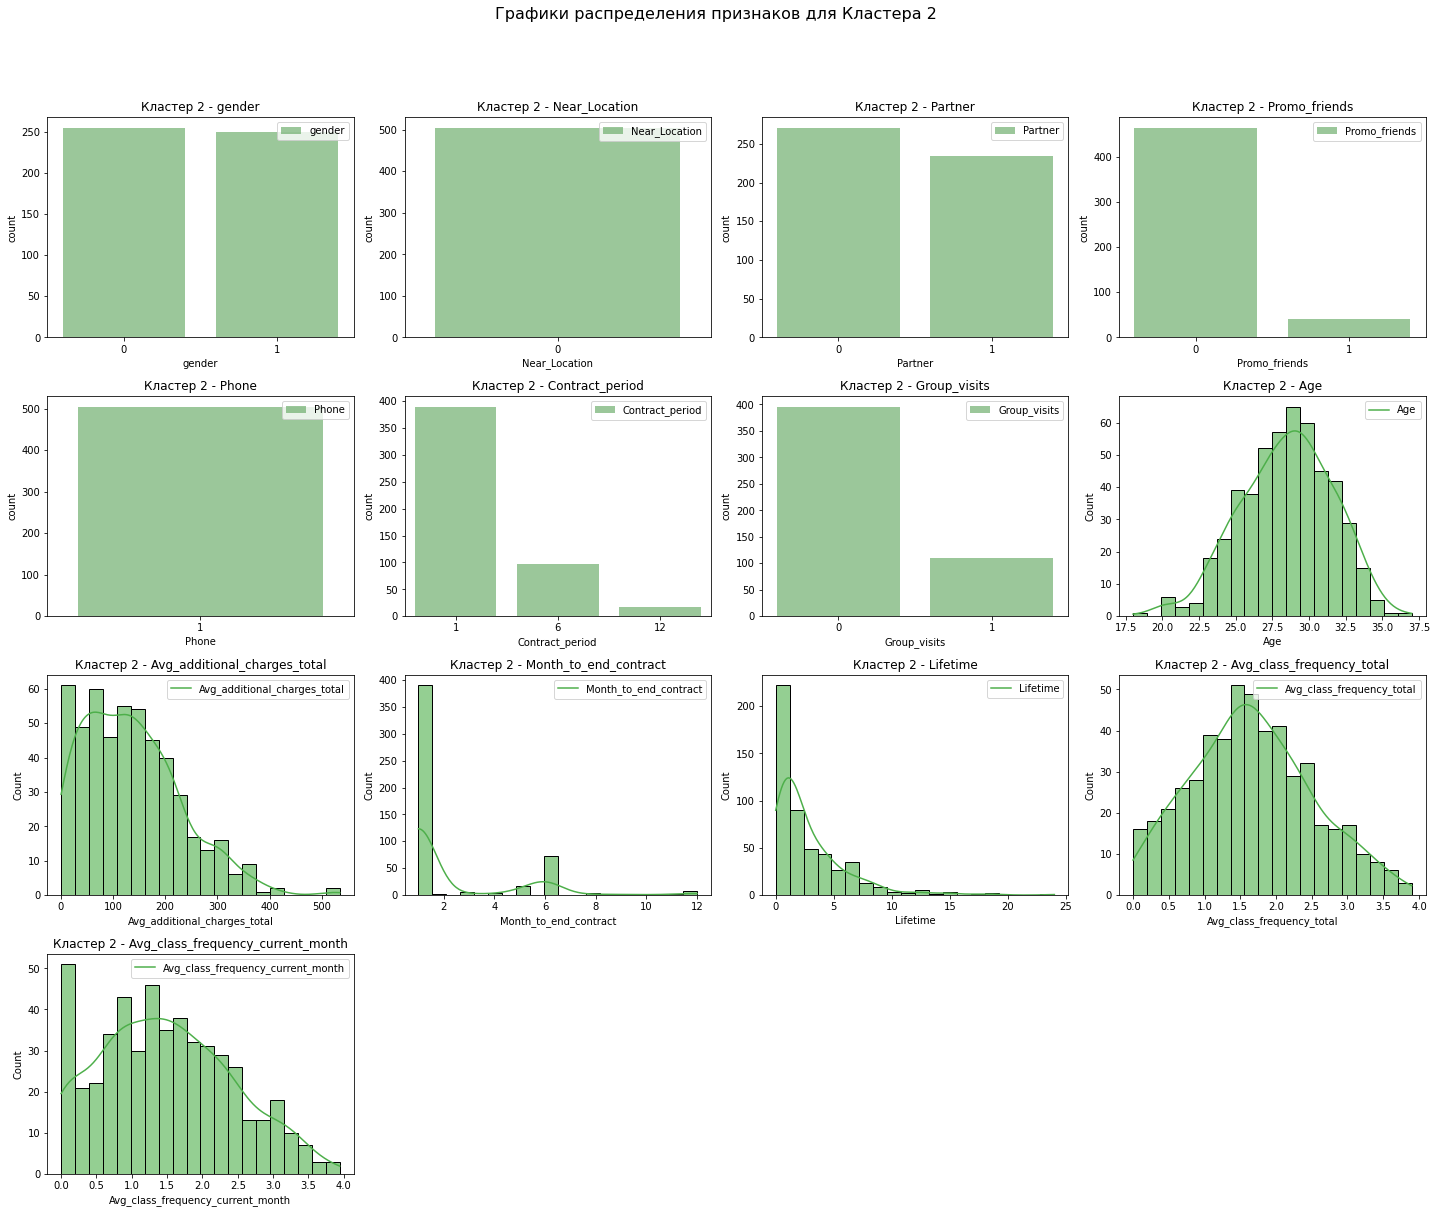

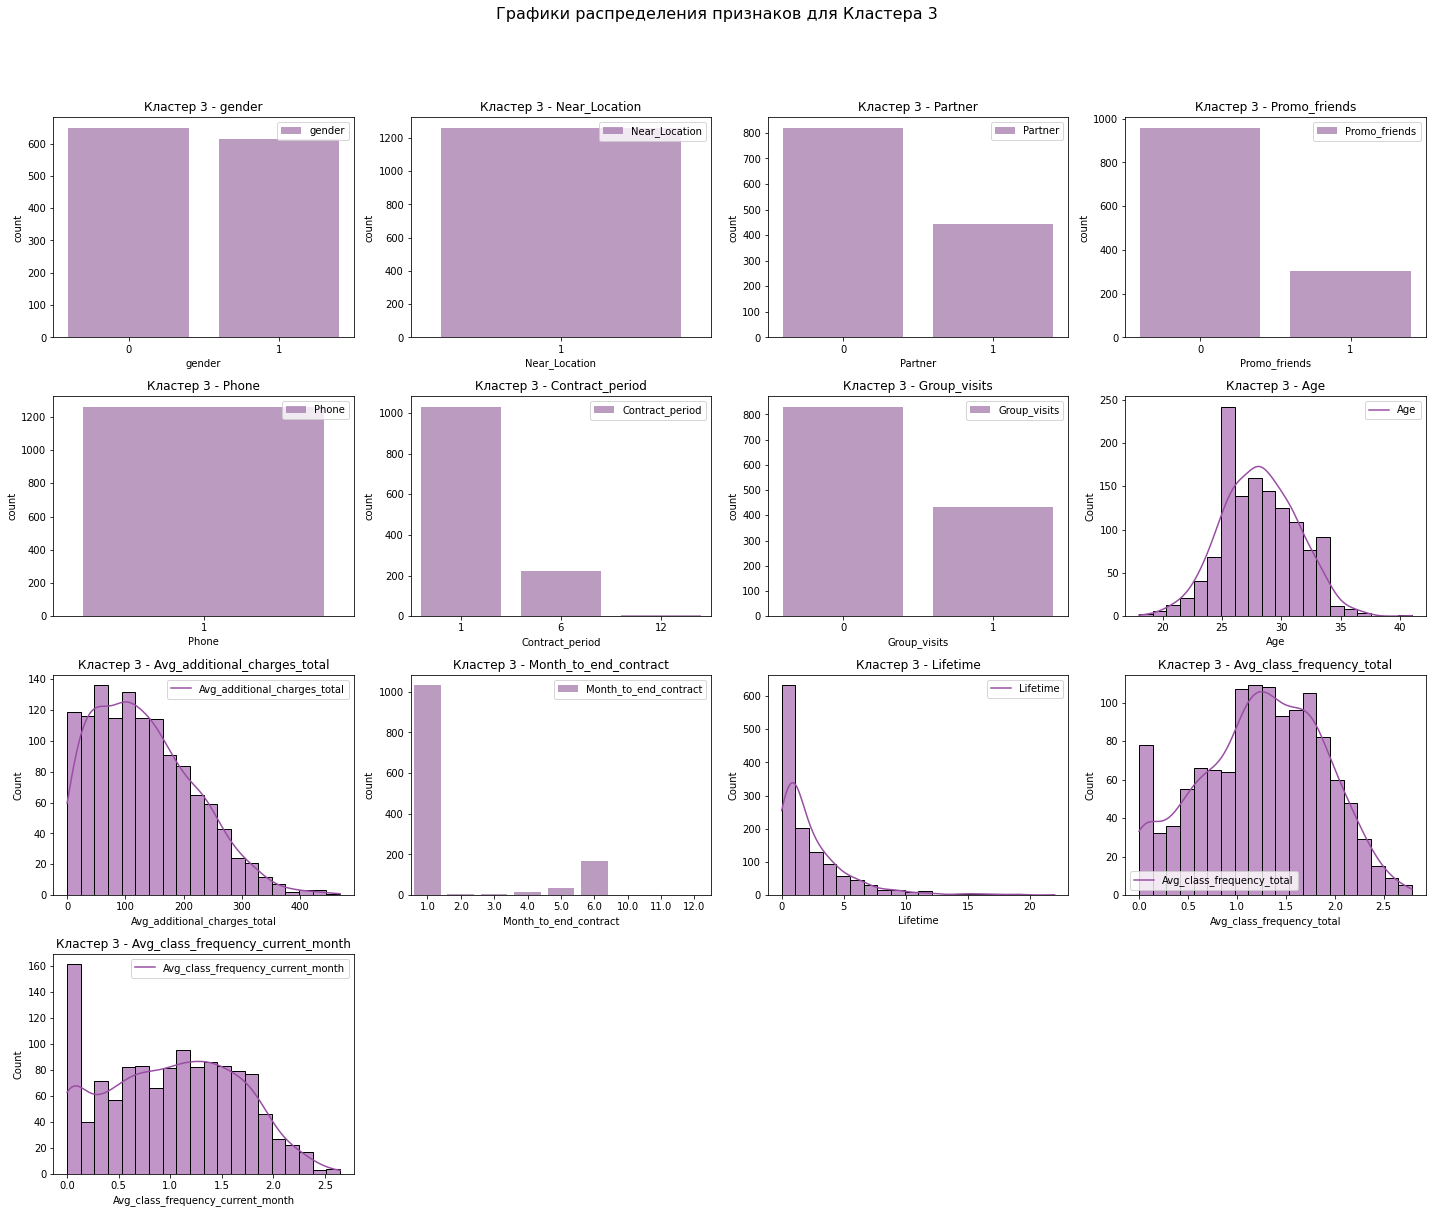

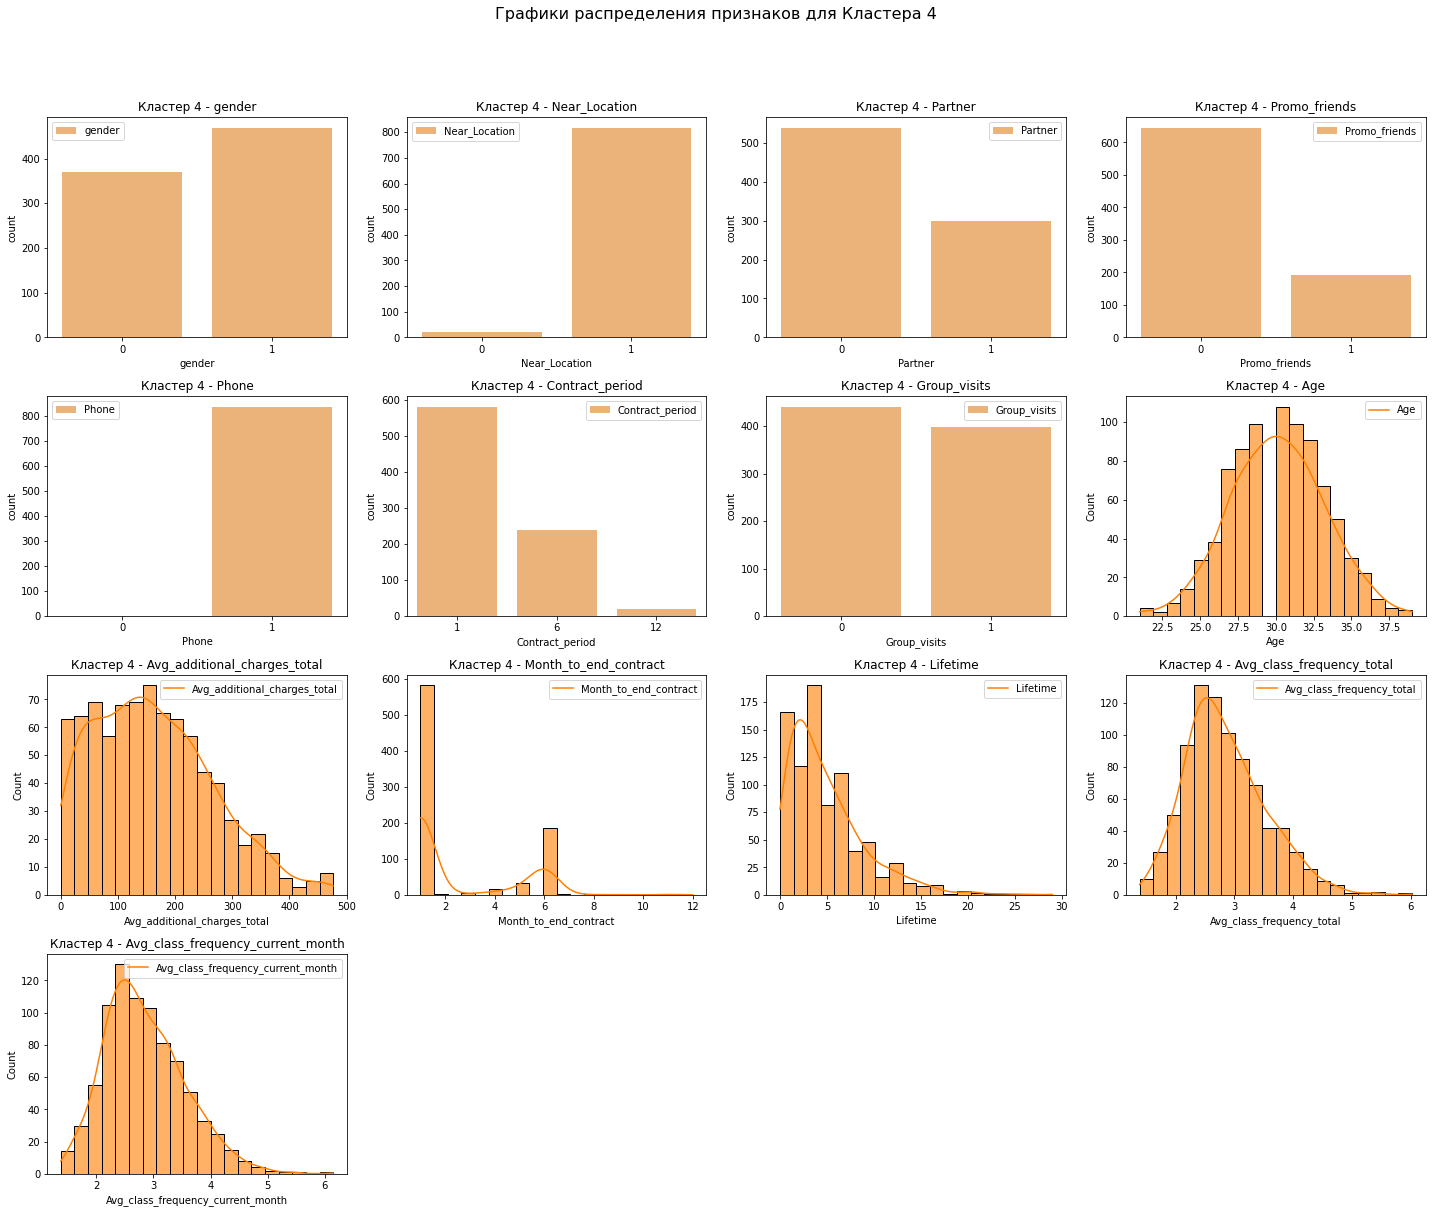

In [21]:
# Список цветов для кластеров
colors = sns.color_palette("Set1", n_colors=5)

# Определяем количество признаков
n_features = len(X.columns)

# Вычисляем количество строк и столбцов для графиков
n_cols = 4  # Например, 4 столбца
n_rows = int(np.ceil(n_features / n_cols))  # Количество строк, зависит от числа признаков

# Создаем графики для каждого кластера
for cluster in range(5):
    plt.figure(figsize=(n_cols * 5, n_rows * 4))  # Размер графиков в зависимости от количества
    for i, column in enumerate(X.columns):
        plt.subplot(n_rows, n_cols, i + 1)  # Автоматически заполняем сетку
        cluster_data = gym_churn[gym_churn['cluster_km'] == cluster]
        
        if cluster_data[column].dtype == 'object' or cluster_data[column].nunique() < 10:  # Для категориальных признаков
            sns.countplot(data=cluster_data, x=column, color=colors[cluster], alpha=0.6)
            plt.title(f'Кластер {cluster} - {column}')
        else:  # Для количественных признаков
            sns.histplot(cluster_data[column], kde=True, color=colors[cluster], alpha=0.6, bins=20)
            plt.title(f'Кластер {cluster} - {column}')
        
        plt.legend([f'{column}'])
    
    plt.suptitle(f'Графики распределения признаков для Кластера {cluster}', fontsize=16, y=1.05)  # Добавляем заголовок для группы графиков
    plt.tight_layout()
    plt.show()

- По графикам можно заметить что по полу распределение для всех кластеров примерно одинаково равномерное(только кластер 3 и 4 показывают преобладание клиентов женского пола(3) и мужского пола(4)
- у всех кластеров, кроме 3-его, близкое местонахождение пользователей к фитнес-клубу
- у всех кластеров, кроме 0-ого, люди являются в большинстве случаев сотрудниками партнерских компаний или пришли по акции
- во всех случаях преобладает невысокая длительность абонементов(около 2 мес), кроме кластера 0(12 мес)
- наиболее высокие показатели по посещаемости групповых занятий у кластера 0, а самые низкие у кластера 2
- самое длительное время с момента первого обращения в фитнес-центр (в месяцах) у кластера 4, а самое малое у кластеров 3 и 2
- средняя частота посещений в неделю за все время с начала действия абонемента у кластера 4 около 2-3 раз, у кластера 3 в районе 1 раза, у кластера 2 : 1-2 раза, у кластера 1 : 2 раза и у кластера 0 : 2-3 раза

### Шаг 5. Сформулируем выводы и сделаем базовые рекомендации по работе с клиентами

Таким образом:
1. Общие характеристики клиентов:
	-	Распределение пола: Мужчины и женщины представлены в равной пропорции.
	-	Близость к фитнес-центру: 85% клиентов живут или работают рядом с клубом, что положительно сказывается на их посещаемости.
	-	Сотрудники компаний-партнёров или участники акции: Около половины клиентов пользуются корпоративным сотрудничеством или пришли по акции-рекомендации, что говорит о важности работы с партнёрскими программами.
	-	Возраст: Средний возраст клиента — 29 лет. В группе оттока преобладает более низкий возраст (27-28 лет).
	-	Групповые занятия: Только 40% клиентов посещают групповые тренировки. В группе оттока доля таких клиентов ещё ниже.
	-	Среднее время с момента первого обращения: У большинства клиентов стаж в фитнес-центре составляет около 4 месяцев, но у клиентов в оттоке — только 1 месяц.
	-	Длительность абонемента: В среднем 5 месяцев, однако клиенты в оттоке чаще покупают краткосрочные абонементы (1-2 месяца).
	-	Дополнительные расходы: Средняя сумма, потраченная на дополнительные услуги (кафе, спорттовары, массаж), составляет 146 единиц, но у клиентов в оттоке она значительно ниже.
	-	Общий уровень оттока: Отток составляет 27%. Это значительное число, требующее работы для его снижения.

2. Основные различия между группами оттока и оставшихся клиентов:
-	Клиенты в оттоке:
	-	Меньше тратят на дополнительные услуги (115 против 158 у оставшихся).
	-	Живут дальше от фитнес-центра.
	-	Чаще выбирают краткосрочные контракты (1-2 месяца).
	-	Реже посещают групповые занятия.
	-	Имеют меньший срок с момента первого обращения (всего около 1 месяца).
-	Клиенты, которые остаются:
	-	Дольше остаются с клубом (время с первого посещения — около 5 месяцев).
	-	Чаще выбирают длительные абонементы (6-12 месяцев).
    -   Живут рядом с фитнес-центром
	-	Более активны в посещениях и чаще участвуют в групповых занятиях.
	-	Более склонны пользоваться дополнительными услугами клуба.

3. Анализ кластеров:

Было выделено 5 кластеров клиентов с разной вероятностью оттока:

- 	Кластер 0 (самые лояльные клиенты):
	-	Самый низкий уровень оттока (2.8%).
	-	Большинство клиентов живут рядом, участвуют в акциях «Приведи друга», имеют долгосрочные абонементы (10 месяцев) и высокую активность в групповых занятиях.
	-	Чаще всего пользуются дополнительными услугами (выручка 161 единица).
-	Кластер 1 (средний риск оттока):
	-	Уровень оттока составляет 27%.
	-	Клиенты живут близко, но чаще выбирают краткосрочные контракты (5 месяцев).
	-	Средние траты на дополнительные услуги (144 единицы).
- 	Кластер 2 (высокий отток):
	-	Уровень оттока составляет 44%.
	-	Клиенты живут далеко, редко посещают групповые занятия и пользуются краткосрочными контрактами (2 месяца).
-	Кластер 3 (максимальный отток):
	-	Уровень оттока — 51%.
	-	Преобладают женщины, живущие далеко от фитнес-центра.
	-	Очень низкая активность в занятиях и использование краткосрочных абонементов (2 месяца).
	-	Минимальные траты на дополнительные услуги (131 единица).
-	Кластер 4 (низкий отток):
	-	Уровень оттока — 6.8%.
	- 	Преобладают мужчины, живущие рядом, со средней активностью в занятиях.
	-	Средняя продолжительность абонемента — 2.5 месяца, траты на дополнительные услуги — 161 единица.

Основные выводы:
1.	Длительность абонемента — ключевой фактор удержания: Клиенты с долгосрочными контрактами реже попадают в отток.
2.	Близость к фитнес-центру также является важным фактором: клиенты, живущие далеко, более склонны к оттоку.
3.	Активность и посещаемость напрямую связаны с удержанием. Групповые занятия и частые посещения мотивируют клиентов оставаться.
4.	Дополнительные услуги играют важную роль: клиенты, активно использующие кафе, массаж или другие сервисы, реже уходят.
5.	Новички наиболее подвержены оттоку: Клиенты, посещающие центр менее месяца, наиболее склонны уходить.

Рекомендации: 
-	Выделить клиентов из кластеров с высоким риском оттока (2 и 3) и проактивно работать с ними, предлагая программы лояльности, бонусы или индивидуальные условия. Например в кластере, где преобладают женщины, направить рекламу и акционные предложения, которые будут интересны именно данному полу(скидки на доп.услуги(массаж, косметический салон)

-	Разработать специальные предложения для продления абонементов, например, скидки за переход на более долгосрочные контракты (6-12 месяцев).

-	Активно продвигать групповые занятия через бесплатные пробные уроки. Организовать системы уведомлений и напоминаний для клиентов, которые перестали посещать занятия.

-	Ввести программы адаптации для новичков (например, бесплатные консультации с тренерами, сопровождение в течение первого месяца). Разработать персонализированные планы тренировок и предложений для новичков.

- Работа с клиентами, живущими далеко:
	- Внедрить дополнительные онлайн-услуги, такие как тренировки или консультации.
	- Предложить транспортные бонусы или организовать совместные поездки.

- Увеличение доходов от дополнительных услуг:
	-	Развивать инфраструктуру (кафе, косметический салон, массаж), так как она напрямую влияет на удержание.
	-	Предложить скидки или акции на дополнительные услуги для клиентов, продлевающих контракты.

Реализация данных рекомендаций поможет снизить отток, повысить вовлечённость клиентов и увеличить доход фитнес-центра.